# 01. EDA — Day 1 핵심 결과 재현

Day 1 산출물(`DS-MINI-Design-울산캠퍼스_2반-안동선+김민솔.pdf`)의 Q1~Q5 핵심 그림을 캐시 데이터로 재현한다.

- 데이터 캐시: `python -m src.preprocess` (최초 1회)

In [1]:
# ── 공통 설정 ──────────────────────────────────────────────
import sys
from pathlib import Path

# notebooks/ 에서 실행해도 프로젝트 루트의 src 패키지를 import 할 수 있도록 경로 추가
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트(macOS) + 마이너스 기호 깨짐 방지
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font="AppleGothic")

# 배치별 색상 (Day 1 산출물과 동일한 톤)
BATCH_COLOR = {"B1": "#2f6b9a", "B2": "#c77d2a", "B3": "#7f5aa6"}

from src.preprocess import load_cache
from src.features import build_features, delta_q

# cells   : 셀 메타정보 (batch, policy, cycle_life, last_QD ...)
# summary : 사이클별 요약 (QD, IR, 온도, 충전시간)
# qdlin   : {"셀ID|사이클인덱스": Qdlin 배열(1,000 전압점)}
cells, summary, qdlin = load_cache()

# 레이블(cycle_life) 보유 셀의 피처 테이블 — B1 46 / B2 39 / B3 44셀
feat = build_features()

# 배치별 셀 수 · 종료 근접(마지막 QD ≤ 0.885 Ah) 셀 수 · 수명 중앙값
feat.groupby("batch").agg(n=("cell_id", "size"), near_eol=("near_eol", "sum"),
                          life_median=("cycle_life", "median"))

,n,near_eol,life_median
batch,,,
B1,46,36,858.5
B2,39,39,472.0
B3,44,44,1005.5


## Q1. Cycle Life 분포
- B1에는 500 미만 셀이 없고, B2는 71.8%가 500 미만 → **B1에 없는 단수명 구간을 B2에서 평가**

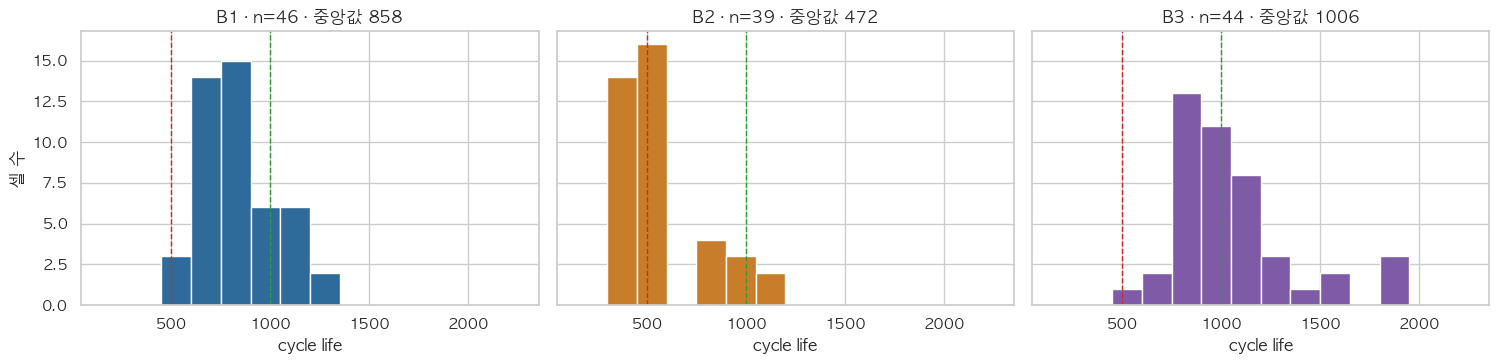

,under_500,over_1000
batch,,
B1,0.0,21.7
B2,71.8,7.7
B3,0.0,52.3


In [2]:
# 배치별 수명 히스토그램 (세 배치 동일 구간 150~2,300)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
bins = np.arange(150, 2350, 150)
for ax, (b, g) in zip(axes, feat.groupby("batch")):
    ax.hist(g["cycle_life"], bins=bins, color=BATCH_COLOR[b], edgecolor="white")
    # 단수명(<500) · 장수명(>1,000) 기준선
    ax.axvline(500, color="tab:red", ls="--", lw=1); ax.axvline(1000, color="tab:green", ls="--", lw=1)
    ax.set_title(f"{b} · n={len(g)} · 중앙값 {g.cycle_life.median():.0f}"); ax.set_xlabel("cycle life")
axes[0].set_ylabel("셀 수"); plt.tight_layout(); plt.show()

# 단수명(<500) / 장수명(>1,000) 비율 (%)
feat.groupby("batch")["cycle_life"].agg(
    under_500=lambda s: (s < 500).mean() * 100, over_1000=lambda s: (s > 1000).mean() * 100).round(1)

## Q2. 열화 곡선
- 급변(knee)은 예측 시점(100사이클) 이후에 나타남 → 전체 경로 기반 knee는 입력에서 제외
- 10→100사이클 감소 속도는 장·단수명 차이가 없고, 마지막 20% 구간에서 단수명 셀이 1.5~1.8배 빠름

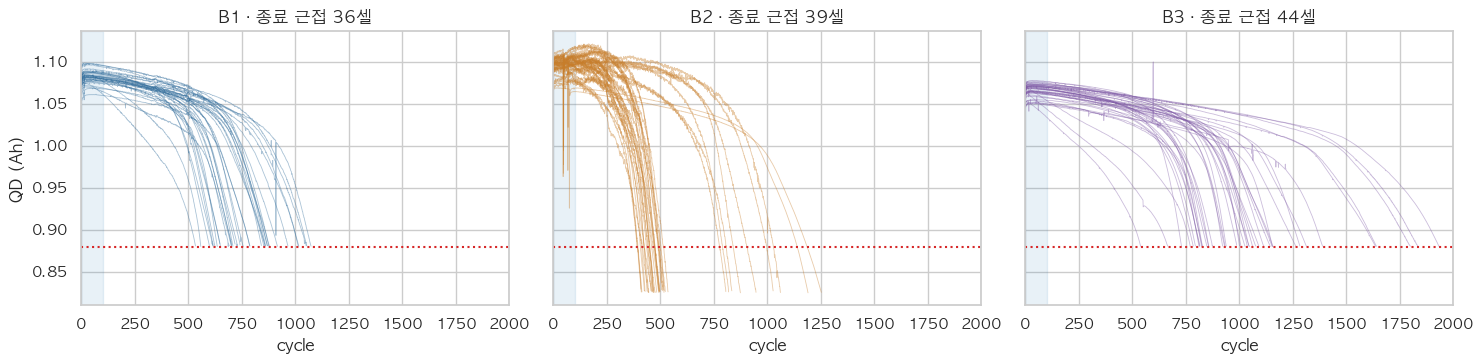

In [3]:
# 종료 근접 셀의 사이클별 방전용량(QD) 곡선
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
use = feat[feat["near_eol"]]
for ax, (b, g) in zip(axes, use.groupby("batch")):
    for cid in g["cell_id"]:
        # 0.8~1.2 Ah 밖의 값은 측정 스파이크로 보고 그리지 않음
        s = summary[(summary.cell_id == cid) & summary.QD.between(0.8, 1.2)]
        ax.plot(s["cycle"], s["QD"], color=BATCH_COLOR[b], lw=0.6, alpha=0.4)
    ax.axvspan(0, 100, color="tab:blue", alpha=0.1)   # 모델 입력 구간 (초기 100사이클)
    ax.axhline(0.88, color="tab:red", ls=":")          # EOL = 공칭 1.1 Ah의 80%
    ax.set_title(f"{b} · 종료 근접 {len(g)}셀"); ax.set_xlabel("cycle"); ax.set_xlim(0, 2000)
axes[0].set_ylabel("QD (Ah)"); plt.tight_layout(); plt.show()

In [4]:
# 장수명 vs 단수명 열화 속도 (mAh/사이클, 감소가 양수) — 종료 근접 셀, 배치별 수명 하위·상위 1/3 중앙값
#   early: 10→100사이클 (모델 입력 구간) / late: 수명 마지막 20% 구간
def fade_rates(cid, life):
    g = summary[(summary.cell_id == cid) & summary.QD.between(0.8, 1.2)].set_index("cycle")["QD"]
    q = lambda c: g.loc[c - 2:c + 2].median()   # 측정 잡음 완화: 앞뒤 2사이클 중앙값
    return {"early": (q(10) - q(100)) * 1000 / 90,
            "late": (q(int(life * 0.8)) - g.iloc[-1]) * 1000 / (life * 0.2)}

fade = use[["cell_id", "batch", "cycle_life"]].join(
    pd.DataFrame([fade_rates(c, l) for c, l in zip(use.cell_id, use.cycle_life)], index=use.index))
rows = []
for b, g in fade.groupby("batch"):
    lo, hi = g.cycle_life.quantile([1/3, 2/3])
    for name, sub in [("단수명 하위 1/3", g[g.cycle_life <= lo]), ("장수명 상위 1/3", g[g.cycle_life >= hi])]:
        rows.append({"batch": b, "group": name, "n": len(sub), **sub[["early", "late"]].median().round(3)})
pd.DataFrame(rows)

,batch,group,n,early,late
0,B1,단수명 하위 1/3,12,0.020,1.004
1,B1,장수명 상위 1/3,12,0.009,0.682
2,B2,단수명 하위 1/3,14,-0.012,2.290
3,B2,장수명 상위 1/3,13,0.014,1.275
4,B3,단수명 하위 1/3,15,0.012,0.752
5,B3,장수명 상위 1/3,15,0.016,0.472


## Q3. ΔQ(V) = Q100(V) − Q10(V)
- 수명 하위 1/3의 전압별 변화가 더 큼 → 분산으로 불균일성을 요약 (`log10 var(ΔQ)`)

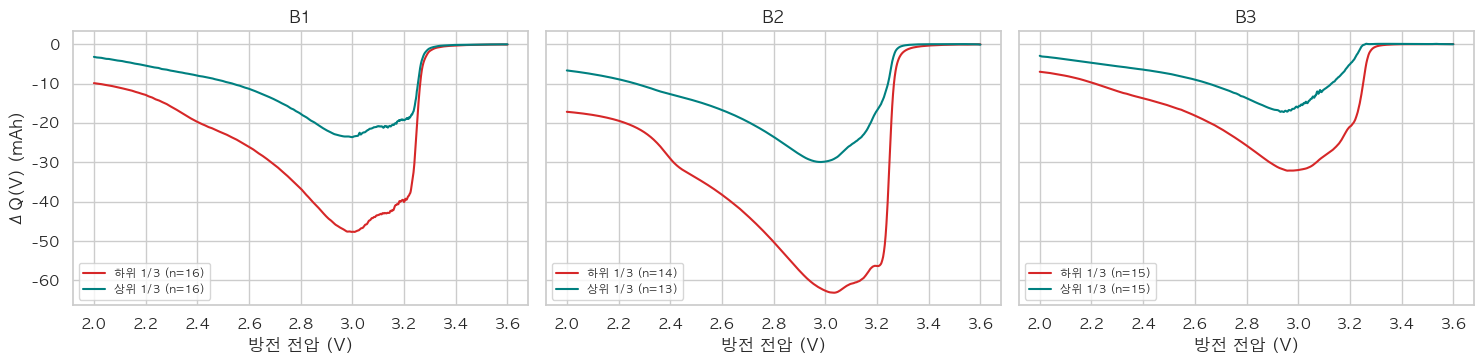

In [5]:
# Qdlin 은 3.6V → 2.0V 구간을 1,000점으로 선형 보간한 방전 용량
V = np.linspace(3.6, 2.0, 1000)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
for ax, (b, g) in zip(axes, feat.groupby("batch")):
    # 배치 안에서 수명 하위 1/3 vs 상위 1/3
    lo, hi = g["cycle_life"].quantile([1/3, 2/3])
    for name, sub, color in [("하위 1/3", g[g.cycle_life <= lo], "tab:red"), ("상위 1/3", g[g.cycle_life >= hi], "teal")]:
        # 셀별 ΔQ(V) 곡선(mAh)을 쌓아 평균 곡선을 그림
        curves = np.stack([delta_q(qdlin, c) * 1000 for c in sub["cell_id"]])
        ax.plot(V, curves.mean(0), color=color, label=f"{name} (n={len(sub)})")
    ax.set_title(b); ax.set_xlabel("방전 전압 (V)"); ax.legend(fontsize=8)
axes[0].set_ylabel("ΔQ(V) (mAh)"); plt.tight_layout(); plt.show()

## Q4. 충전 조건과 수명
- 최대 전류가 큰 정책일수록 수명이 짧음 → 원정책(C1·C2·SOC1)과 파생정책(평균 C·최대 C)을 후보로

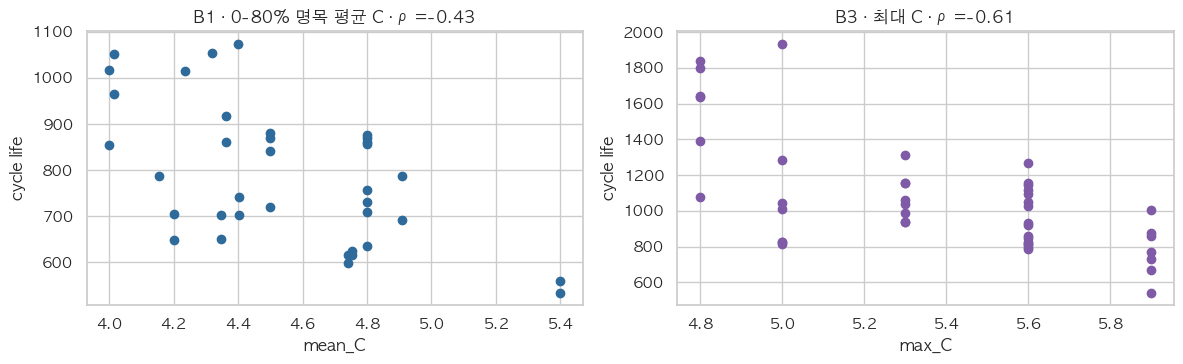

In [6]:
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
b1 = feat[(feat.batch == "B1") & feat.near_eol]   # B1 종료 근접 36셀
b3 = feat[feat.batch == "B3"]
# B1은 명목 평균 C, B3는 최대 C 기준으로 수명과의 순위 상관(Spearman) 확인
for ax, d, x, title in [(axes[0], b1, "mean_C", "B1 · 0-80% 명목 평균 C"), (axes[1], b3, "max_C", "B3 · 최대 C")]:
    ax.scatter(d[x], d["cycle_life"], color=BATCH_COLOR[d.batch.iloc[0]])
    ax.set_title(f"{title} · ρ={spearmanr(d[x], d.cycle_life)[0]:.2f}"); ax.set_xlabel(x); ax.set_ylabel("cycle life")
plt.tight_layout(); plt.show()

## Q5. 상관관계와 중복
- ΔQ 통계가 세 배치 모두에서 가장 강함 (log var: −0.87 / −0.71 / −0.80)
- ΔQ 분산·평균·최솟값은 서로 |ρ|≥0.97 → 분산 하나만 사용

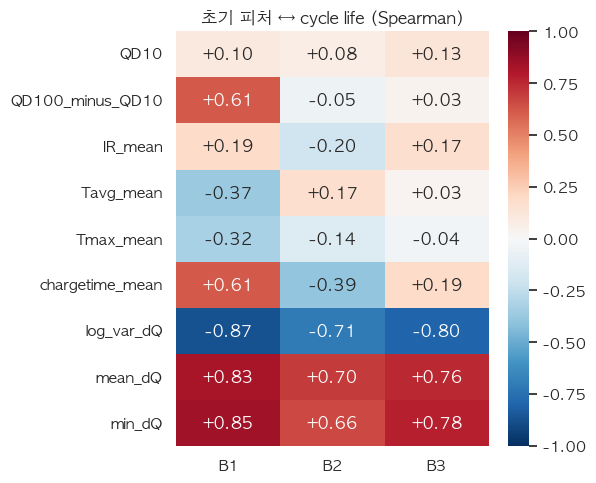

In [7]:
# 초기 사이클 피처 후보 (summary 통계 + ΔQ 통계)
cols = ["QD10", "QD100_minus_QD10", "IR_mean", "Tavg_mean", "Tmax_mean", "chargetime_mean",
        "log_var_dQ", "mean_dQ", "min_dQ"]

# 배치별로 각 피처 ↔ cycle life Spearman 상관 (IR 0값 등 결측은 제외)
corr = pd.DataFrame({b: [spearmanr(g[c], g.cycle_life, nan_policy="omit")[0] for c in cols]
                     for b, g in feat.groupby("batch")}, index=cols)

plt.figure(figsize=(6, 5)); sns.heatmap(corr, annot=True, fmt="+.2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("초기 피처 ↔ cycle life (Spearman)"); plt.tight_layout(); plt.show()